# TP2 — Reconstrucción 3D con cámara estéreo

**I308 Visión Artificial · UdeSA · Santiago Luis Groba Alonso**

Reconstrucción 3D de un objeto rígido (buda) a partir de pares de imágenes RGB capturados con la cámara estéreo ELP-USB3D1080P02-H120. Las celdas markdown describen, en pasado, lo que hace cada etapa — sirven tanto de guía para escribir el código como de borrador para el informe.

## 0. Setup

Importamos las librerías que usa todo el notebook (`cv2`, `numpy`, `matplotlib`, `open3d`, `tqdm`, `pickle`) y el módulo local `aruco.py` con las helpers de ChArUco copiadas del ejemplo de cátedra. Definimos los paths del dataset (`datasets/stereo_propio/`), las dimensiones del patrón ChArUco usado en escena (5×7, square 52.6 mm, marker 31.3 mm, dictionary `DICT_6X6_250`), los parámetros de SGBM (numDisparities=128, blockSize=5) y el bounding box en coordenadas de mundo que vamos a usar más adelante para recortar el objeto.

In [ ]:
import pickle
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import open3d as o3d
from tqdm import tqdm

import aruco  # helpers de ChArUco (copiadas del ejemplo de catedra)

# --- Dataset ---
DATASET_DIR = Path("datasets/stereo_propio")
CAPTURES_DIR = DATASET_DIR / "captures"
CALIB_PKL = DATASET_DIR / "stereo_calibration.pkl"

# --- Patron ChArUco usado en escena (5x7, square 52.6 mm, marker 31.3 mm) ---
CHARUCO_SQUARES_X = 5
CHARUCO_SQUARES_Y = 7
CHARUCO_SQUARE_MM = 52.6
CHARUCO_MARKER_MM = 31.3
CHARUCO_DICT = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_6X6_250)

# --- SGBM ---
SGBM_NUM_DISPARITIES = 192   # multiplo de 16 (rango de busqueda de disparidad)
SGBM_BLOCK_SIZE = 7          # impar; mas grande -> mas robusto en zonas lisas

# --- Filtros para la nube de puntos ---
MIN_DEPTH_MM = 100
MAX_DEPTH_MM = 2000
VOXEL_SIZE_MM = 1.0
OUTLIER_NB_NEIGHBORS = 20
OUTLIER_STD_RATIO = 2.0

# Bounding box en coordenadas de mundo [x0, y0, z0, x1, y1, z1] (mm).
# Descarta el plano del ChArUco y todo lo que no sea el buda.
BBOX_WORLD_MM = np.array([-200, -200, -50, 200, 200, 400], dtype=np.float32)

print("Setup OK")

## 1. Calibración estéreo

Usamos la herramienta de cátedra [i308-calib](https://github.com/udesa-vision/i308-calib) sobre nuestro set de calibración (~163 pares de un checkerboard 10×7 de lado 24.2 mm) para obtener los intrínsecos `K_L`, `K_R`, las distorsiones `D_L`, `D_R` y los extrínsecos `R`, `T` que relacionan ambas cámaras. La herramienta deja todo serializado en `stereo_calibration.pkl`, que en esta celda cargamos con `pickle` e inspeccionamos. Verificamos que el baseline observado `||T||` quede cerca de los 60 mm declarados por el fabricante de la ELP-USB3D1080P02-H120.

In [4]:
# Cargamos la calibracion estereo serializada por i308-calib
with open(CALIB_PKL, "rb") as f:
    calib = pickle.load(f)

K_L = calib["left_K"]      # intrinsecos camara izquierda
D_L = calib["left_dist"]   # distorsion camara izquierda
K_R = calib["right_K"]     # intrinsecos camara derecha
D_R = calib["right_dist"]  # distorsion camara derecha
R = calib["R"]             # rotacion left -> right
T = calib["T"]             # traslacion left -> right (mm)
IMAGE_SIZE = calib["image_size"]  # (width, height)

# Sanity check: baseline de la ELP-USB3D1080P02-H120 segun fabricante ~60 mm
baseline_mm = float(np.linalg.norm(T))
print(f"image_size : {IMAGE_SIZE}")
print(f"baseline   : {baseline_mm:.2f} mm (esperado ~60 mm)")

print("\nContenido del pickle:")
for key, value in calib.items():
    shape = value.shape if isinstance(value, np.ndarray) else value
    print(f"  {key:11s} -> {shape}")

print(f"\nK_L =\n{K_L}")
print(f"\nK_R =\n{K_R}")
print(f"\nD_L = {D_L.ravel()}")
print(f"\nD_R = {D_R.ravel()}")
print(f"\nR =\n{R}")
print(f"\nT = {T.ravel()}")

image_size : (1920, 1080)
baseline   : 59.91 mm (esperado ~60 mm)

Contenido del pickle:
  left_K      -> (3, 3)
  left_dist   -> (1, 5)
  right_K     -> (3, 3)
  right_dist  -> (1, 5)
  R           -> (3, 3)
  T           -> (3, 1)
  E           -> (3, 3)
  F           -> (3, 3)
  image_size  -> (1920, 1080)

K_L =
[[596.39327252   0.         968.17885414]
 [  0.         595.66459103 543.15708942]
 [  0.           0.           1.        ]]

K_R =
[[596.55879619   0.         948.26194037]
 [  0.         595.86059254 532.18083804]
 [  0.           0.           1.        ]]

D_L = [ 0.00305256 -0.02313543  0.00037708  0.00028137  0.00356032]

D_R = [ 4.84387071e-03 -2.47947764e-02  5.15747606e-05 -7.75385969e-04
  3.97490332e-03]

R =
[[ 9.99935455e-01 -8.10028341e-04  1.13326573e-02]
 [ 8.22760768e-04  9.99999036e-01 -1.11889939e-03]
 [-1.13317400e-02  1.12815124e-03  9.99935157e-01]]

T = [-59.90468948  -0.24488926   0.22258718]


## 2. Rectificación

A partir de la calibración llamamos `cv2.stereoRectify` para conseguir las matrices de proyección `P1`, `P2` y la matriz de reproyección `Q` que necesitamos en la etapa de profundidad. Con `cv2.initUndistortRectifyMap` precomputamos los mapas que aplican simultáneamente la des-distorsión y la rectificación a cada lado. Definimos una función `rectify(left, right)` que envuelve `cv2.remap` para usarla cómodamente en el loop. Visualizamos un par original vs rectificado con líneas horizontales superpuestas para confirmar que las epipolares quedaron alineadas a las filas — pre-condición para que el matching estéreo funcione como búsqueda 1D.

P1 =
[[597.24970122   0.         951.67434692   0.        ]
 [  0.         597.24970122 538.49272919   0.        ]
 [  0.           0.           1.           0.        ]]
P2 =
[[ 5.97249701e+02  0.00000000e+00  9.51674347e+02 -3.57786038e+04]
 [ 0.00000000e+00  5.97249701e+02  5.38492729e+02  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  1.00000000e+00  0.00000000e+00]]
Q  =
[[ 1.00000000e+00  0.00000000e+00  0.00000000e+00 -9.51674347e+02]
 [ 0.00000000e+00  1.00000000e+00  0.00000000e+00 -5.38492729e+02]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  5.97249701e+02]
 [ 0.00000000e+00  0.00000000e+00  1.66929292e-02 -0.00000000e+00]]

roi izquierdo : (0, 0, 1920, 1080)
roi derecho   : (0, 0, 1920, 1080)

baseline efectivo (-P2[0,3]/P2[0,0]): 59.91 mm


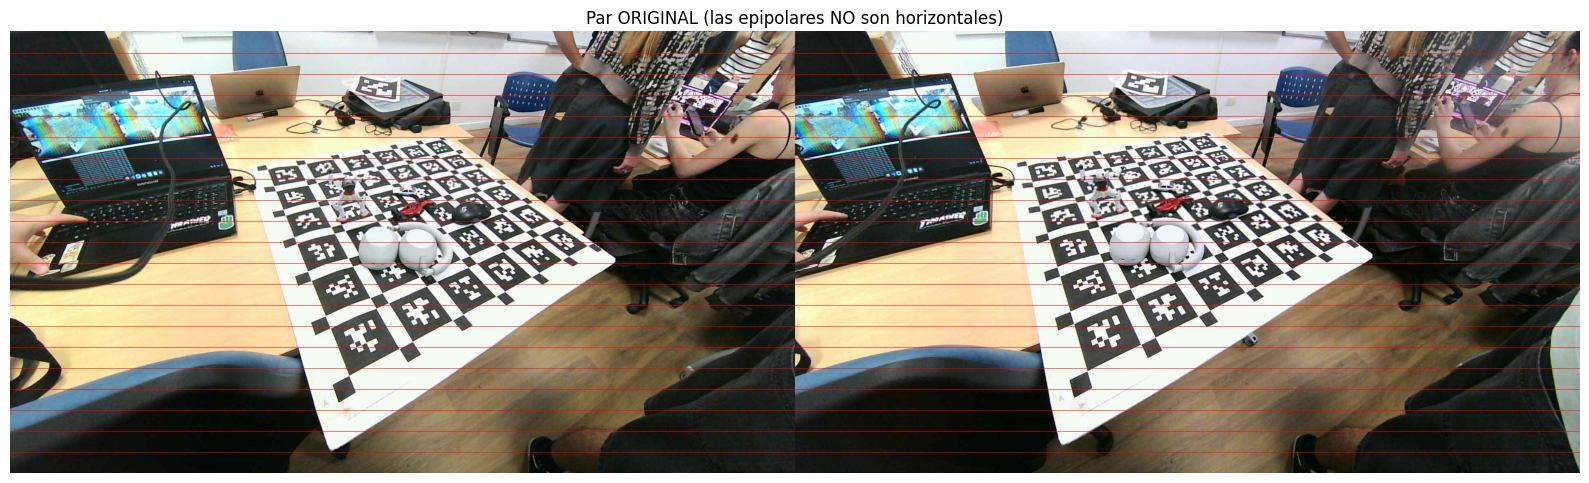

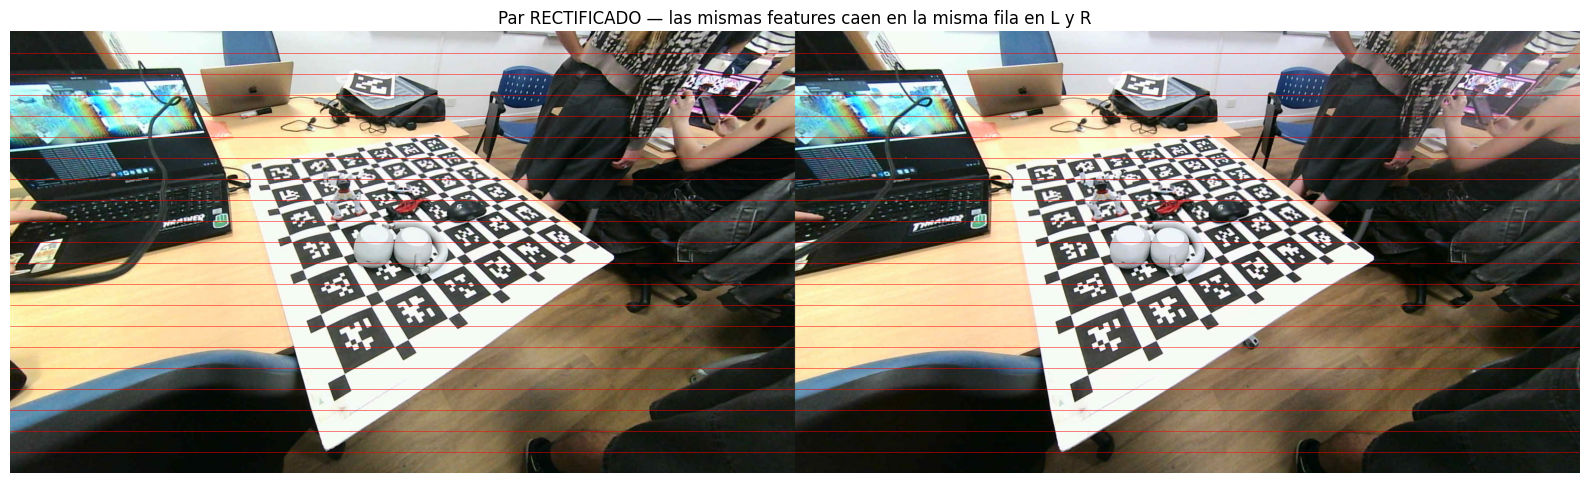

In [5]:
# --- Rectificacion estereo ---
# alpha=0 -> recorta el negro de los bordes (mejor para SGBM); =1 conserva todo
R1, R2, P1, P2, Q, roi_L, roi_R = cv2.stereoRectify(
    K_L, D_L, K_R, D_R, IMAGE_SIZE, R, T,
    flags=cv2.CALIB_ZERO_DISPARITY, alpha=0,
)

# Mapas precomputados que combinan undistort + rectify (CV_16SC2 es mas rapido en remap)
map_L_x, map_L_y = cv2.initUndistortRectifyMap(K_L, D_L, R1, P1, IMAGE_SIZE, cv2.CV_16SC2)
map_R_x, map_R_y = cv2.initUndistortRectifyMap(K_R, D_R, R2, P2, IMAGE_SIZE, cv2.CV_16SC2)


def rectify(left, right):
    """Aplica los mapas de rectificacion a un par estereo."""
    left_rect = cv2.remap(left, map_L_x, map_L_y, cv2.INTER_LINEAR)
    right_rect = cv2.remap(right, map_R_x, map_R_y, cv2.INTER_LINEAR)
    return left_rect, right_rect


print(f"P1 =\n{P1}")
print(f"P2 =\n{P2}")
print(f"Q  =\n{Q}")
print(f"\nroi izquierdo : {roi_L}")
print(f"roi derecho   : {roi_R}")
print(f"\nbaseline efectivo (-P2[0,3]/P2[0,0]): {-P2[0,3]/P2[0,0]:.2f} mm")


# --- Visualizacion: par original vs rectificado con lineas horizontales ---
def show_pair_with_lines(left, right, title, n_lines=20):
    """Concatena L|R horizontalmente y dibuja lineas para chequear epipolares."""
    L = cv2.cvtColor(left, cv2.COLOR_BGR2RGB)
    R_ = cv2.cvtColor(right, cv2.COLOR_BGR2RGB)
    combined = np.hstack([L, R_])
    h = combined.shape[0]

    fig, ax = plt.subplots(figsize=(16, 5))
    ax.imshow(combined)
    for y in np.linspace(0, h - 1, n_lines + 2)[1:-1]:
        ax.axhline(y=y, color="red", linewidth=0.5, alpha=0.7)
    ax.set_title(title, fontsize=12)
    ax.axis("off")
    plt.tight_layout()
    plt.show()


# Tomamos un par de captures para mostrar
left_raw = cv2.imread(str(CAPTURES_DIR / "left_0.jpg"))
right_raw = cv2.imread(str(CAPTURES_DIR / "right_0.jpg"))
left_rect, right_rect = rectify(left_raw, right_raw)

show_pair_with_lines(left_raw, right_raw,
                     "Par ORIGINAL (las epipolares NO son horizontales)")
show_pair_with_lines(left_rect, right_rect,
                     "Par RECTIFICADO — las mismas features caen en la misma fila en L y R")

## 3. Disparidad

Elegimos Semi-Global Block Matching (`cv2.StereoSGBM_create`) por su mejor cobertura en zonas de textura pobre frente al StereoBM clásico. Como el objeto (buda) es blanco y casi sin textura, aplicamos primero un **CLAHE** (Contrast Limited Adaptive Histogram Equalization) sobre las imágenes en escala de grises para amplificar la poca textura local antes del matching, y a la salida un **filtro WLS** (`cv2.ximgproc.createDisparityWLSFilter`) con el right-matcher correspondiente para suavizar preservando bordes y rellenar huecos. Dividimos por 16 porque OpenCV codifica la disparidad en fracciones de 1/16 píxel. Los parámetros (`blockSize=7`, `numDisparities=192`, `P1, P2 ∝ 3 · blockSize²`, `uniquenessRatio=5`, `speckleWindowSize=100`, `speckleRange=2`, `lambda=8000`, `sigmaColor=1.5`) los ajustamos iterando sobre un par representativo y mirando el mapa con un colormap de matplotlib.

disparidad   min=0.06 px, max=126.94 px, mean=53.12 px
cobertura    93.3% de los pixeles tienen match valido
profundidad  ~282 mm a ~572458 mm (Z = f*B/disp)


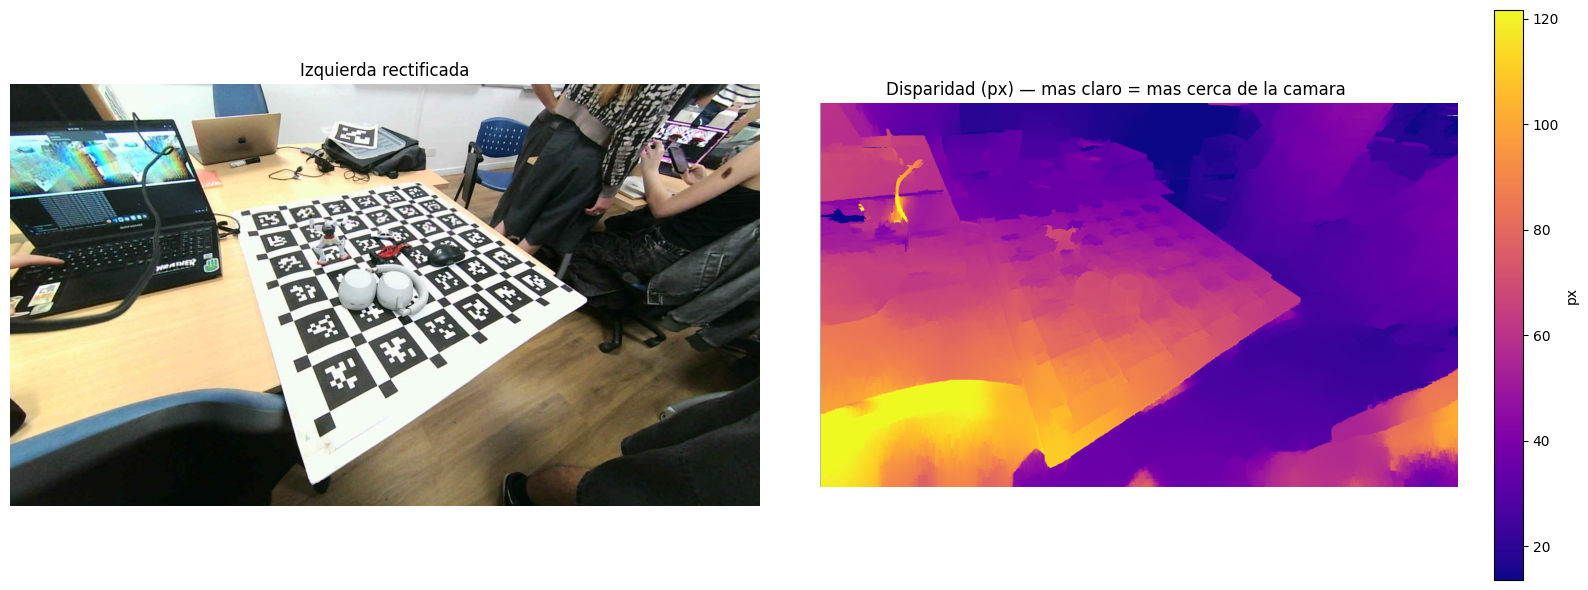

In [8]:
# --- CLAHE para amplificar textura local (el buda es muy liso) ---
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))


def preprocess(rect):
    """A escala de grises + CLAHE para que SGBM tenga mas textura sobre la cual matchear."""
    gray = cv2.cvtColor(rect, cv2.COLOR_BGR2GRAY)
    return clahe.apply(gray)


# --- SGBM (left matcher) ---
sgbm = cv2.StereoSGBM_create(
    minDisparity=0,
    numDisparities=SGBM_NUM_DISPARITIES,
    blockSize=SGBM_BLOCK_SIZE,
    P1=8 * 3 * SGBM_BLOCK_SIZE ** 2,
    P2=32 * 3 * SGBM_BLOCK_SIZE ** 2,
    disp12MaxDiff=1,
    uniquenessRatio=5,        # menos estricto -> mejor cobertura en zonas dudosas
    speckleWindowSize=100,
    speckleRange=2,
    mode=cv2.STEREO_SGBM_MODE_SGBM_3WAY,
)

# --- Right matcher + filtro WLS para suavizar y rellenar huecos ---
right_matcher = cv2.ximgproc.createRightMatcher(sgbm)
wls = cv2.ximgproc.createDisparityWLSFilter(sgbm)
wls.setLambda(8000.0)     # mayor lambda -> mas suavidad
wls.setSigmaColor(1.5)    # mayor sigma -> respeta menos los bordes de color


def compute_disparity(left_rect, right_rect):
    """Disparidad SGBM + WLS en pixeles (float32). Invalidas con valor < 0."""
    gray_L = preprocess(left_rect)
    gray_R = preprocess(right_rect)
    disp_L = sgbm.compute(gray_L, gray_R)              # int16, 1/16 px
    disp_R = right_matcher.compute(gray_R, gray_L)
    disp_filtered = wls.filter(disp_L, gray_L, disparity_map_right=disp_R)
    return disp_filtered.astype(np.float32) / 16.0


# Probamos sobre el par ya rectificado en la celda anterior
disparity = compute_disparity(left_rect, right_rect)

valid = disparity > 0
print(f"disparidad   min={disparity[valid].min():.2f} px, "
      f"max={disparity[valid].max():.2f} px, "
      f"mean={disparity[valid].mean():.2f} px")
print(f"cobertura    {valid.mean() * 100:.1f}% de los pixeles tienen match valido")

# Profundidad implicita: Z = f * baseline / disparidad
f_px = P1[0, 0]
b_mm = -P2[0, 3] / P2[0, 0]
z_min = f_px * b_mm / disparity[valid].max()
z_max = f_px * b_mm / disparity[valid].min()
print(f"profundidad  ~{z_min:.0f} mm a ~{z_max:.0f} mm (Z = f*B/disp)")


# --- Visualizacion ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].imshow(cv2.cvtColor(left_rect, cv2.COLOR_BGR2RGB))
axes[0].set_title("Izquierda rectificada")
axes[0].axis("off")

disp_show = np.where(valid, disparity, np.nan)
# Clip por percentiles para evitar que outliers aplasten el rango visual
vmin = float(np.nanpercentile(disp_show, 2))
vmax = float(np.nanpercentile(disp_show, 98))
im = axes[1].imshow(disp_show, cmap="plasma", vmin=vmin, vmax=vmax)
axes[1].set_title("Disparidad (px) — mas claro = mas cerca de la camara")
axes[1].axis("off")
fig.colorbar(im, ax=axes[1], fraction=0.04, label="px")

plt.tight_layout()
plt.show()

## 4. Pose de la cámara respecto al mundo

Para fusionar nubes parciales en un único marco de coordenadas necesitamos saber, para cada par, cómo está orientada la cámara izquierda respecto al mundo. Definimos ese mundo anclando el origen al ChArUco que aparece en cada captura. Creamos el `CharucoBoard` con `aruco.create_charuco_board`, lo detectamos en la imagen izquierda **original** (no la rectificada — los intrínsecos `K_L`, `D_L` describen la imagen sin rectificar) y estimamos la pose con la helper `estimate_camera_pose_with_homography` que resuelve PnP. El resultado (`rvec`, `tvec`) lo convertimos a una matriz homogénea 4×4 `T_wc` con `cv2.Rodrigues`. Para sanity-check proyectamos los ejes del mundo sobre la imagen y los dibujamos en RGB.

## 5. Reconstrucción 3D de un par

Combinando el mapa de disparidad con la matriz `Q`, `cv2.reprojectImageTo3D` nos devuelve un array `(H, W, 3)` con la posición 3D de cada píxel en el frame de la cámara izquierda. Filtramos los píxeles con disparidad ≤ 0 (inválidos) y los puntos fuera del rango razonable de profundidad (100-2000 mm en nuestro setup, suficiente para enmarcar el buda sin traer fondo). Para llevar esos puntos al frame del mundo invertimos `T_wc` analíticamente (`T_cw = [R^T | -R^T·t]`) y aplicamos la transformación homogénea al batch entero. Armamos una `o3d.geometry.PointCloud` con esos puntos y les pegamos los colores del píxel correspondiente en la izquierda rectificada.

## 6. Loop sobre todos los pares + acumulación

Iteramos sobre todos los `(left_i.jpg, right_i.jpg)` del directorio `captures/`, repitiendo para cada par la secuencia rectificar → disparidad → detectar ChArUco → estimar pose → reproyectar a 3D → transformar al mundo. Sobre cada nube parcial aplicamos tres filtros: recorte con un `AxisAlignedBoundingBox` definido en coordenadas de mundo (descarta el plano del patrón y todo lo que esté fuera del bounding box del buda), `remove_statistical_outlier` con 20 vecinos y σ=2 para sacar puntos espurios del matching, y `voxel_down_sample` con voxel de 1 mm para mantener la densidad manejable. Acumulamos sumando las point clouds con `+=`. Llevamos un registro de los pares donde la detección del ChArUco o el solvePnP fallaron y los reportamos al final.

## 7. Exportar `.PLY` y estimar el alto del objeto

Guardamos la nube final con `o3d.io.write_point_cloud(..., write_ascii=False)` para que el archivo quede en binario y pese menos que el formato ASCII de PLY. Para estimar el alto del buda en milímetros calculamos la extensión de la nube sobre el eje vertical del mundo — en nuestro setup ese eje es `Z`, porque el ChArUco está apoyado sobre el plano `XY`. Reportamos también las extensiones sobre `X` e `Y` como sanity-check de que la escala métrica de la reconstrucción tenga sentido, y comparamos el alto estimado contra una medición manual del objeto con regla.